In [1]:
!pip install numpy 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 18.0 MB/s  0:00:00 eta 0:00:01


In [2]:
!pip install matplotlib 

  Using cached matplotlib-3.10.8-cp313-cp313-macosx_10_13_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_10_13_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_10_13_x86_64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_10_13_x86_64.whl (293 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_x86_64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_10_13_x86_64.whl (66 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 33.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/

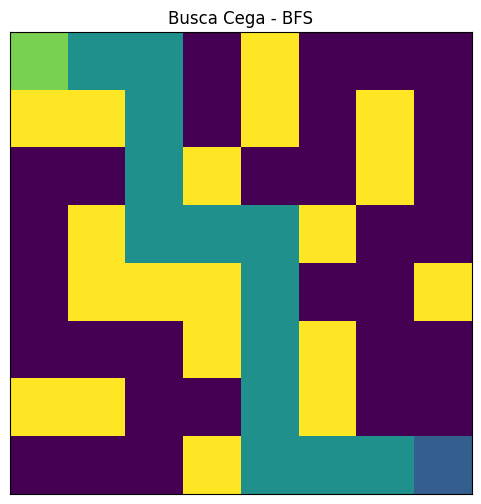

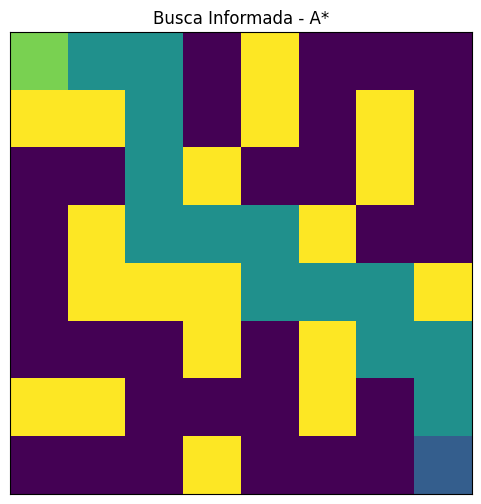

Passos BFS: 15
Passos A* : 15


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from queue import PriorityQueue, Queue

# =========================
# Mapa do labirinto
# 0 = livre
# 1 = parede
# =========================
maze = np.array([
    [0,0,0,0,1,0,0,0],
    [1,1,0,0,1,0,1,0],
    [0,0,0,1,0,0,1,0],
    [0,1,0,0,0,1,0,0],
    [0,1,1,1,0,0,0,1],
    [0,0,0,1,0,1,0,0],
    [1,1,0,0,0,1,0,0],
    [0,0,0,1,0,0,0,0]
])

start = (0,0)   # Pacman
goal  = (7,7)   # Comida

# movimentos possíveis
moves = [(-1,0),(1,0),(0,-1),(0,1)]

# =========================
# Heurística Manhattan
# =========================
def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

# =========================
# BFS (Busca Cega)
# =========================
def bfs(maze, start, goal):
    queue = Queue()
    queue.put(start)
    came_from = {start: None}

    while not queue.empty():
        current = queue.get()

        if current == goal:
            break

        for move in moves:
            neighbor = (current[0]+move[0], current[1]+move[1])

            if (0 <= neighbor[0] < maze.shape[0] and
                0 <= neighbor[1] < maze.shape[1] and
                maze[neighbor] == 0 and
                neighbor not in came_from):

                queue.put(neighbor)
                came_from[neighbor] = current

    return came_from

# =========================
# A* (Busca Informada)
# =========================
def astar(maze, start, goal):
    open_set = PriorityQueue()
    open_set.put((0, start))

    came_from = {start: None}
    g_score = {start: 0}

    while not open_set.empty():
        current = open_set.get()[1]

        if current == goal:
            break

        for move in moves:
            neighbor = (current[0]+move[0], current[1]+move[1])

            if (0 <= neighbor[0] < maze.shape[0] and
                0 <= neighbor[1] < maze.shape[1] and
                maze[neighbor] == 0):

                tentative_g = g_score[current] + 1

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    g_score[neighbor] = tentative_g
                    f_score = tentative_g + heuristic(neighbor, goal)
                    open_set.put((f_score, neighbor))
                    came_from[neighbor] = current

    return came_from

# =========================
# Reconstruir caminho
# =========================
def reconstruct_path(came_from, start, goal):
    current = goal
    path = []

    while current != start:
        path.append(current)
        current = came_from[current]

    path.append(start)
    path.reverse()
    return path

# =========================
# Plot
# =========================
def plot_path(maze, path, title):
    grid = maze.copy().astype(float)

    for p in path:
        grid[p] = 0.5

    grid[start] = 0.8
    grid[goal] = 0.3

    plt.figure(figsize=(6,6))
    plt.imshow(grid)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# =========================
# Executar BFS
# =========================
came_from_bfs = bfs(maze, start, goal)
path_bfs = reconstruct_path(came_from_bfs, start, goal)

# =========================
# Executar A*
# =========================
came_from_astar = astar(maze, start, goal)
path_astar = reconstruct_path(came_from_astar, start, goal)

# =========================
# Mostrar resultados
# =========================
plot_path(maze, path_bfs, "Busca Cega - BFS")
plot_path(maze, path_astar, "Busca Informada - A*")

print("Passos BFS:", len(path_bfs))
print("Passos A* :", len(path_astar))

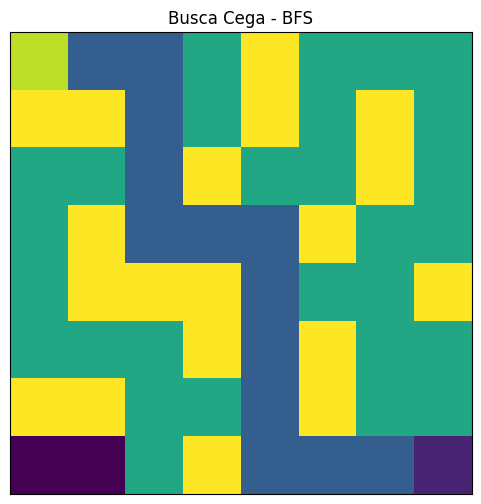

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from queue import PriorityQueue, Queue
from matplotlib import animation
from IPython.display import HTML

# =========================
# Labirinto
# =========================
maze = np.array([
    [0,0,0,0,1,0,0,0],
    [1,1,0,0,1,0,1,0],
    [0,0,0,1,0,0,1,0],
    [0,1,0,0,0,1,0,0],
    [0,1,1,1,0,0,0,1],
    [0,0,0,1,0,1,0,0],
    [1,1,0,0,0,1,0,0],
    [0,0,0,1,0,0,0,0]
])

start = (0,0)
goal = (7,7)

moves = [(-1,0),(1,0),(0,-1),(0,1)]

# =========================
# Heurística Manhattan
# =========================
def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

# =========================
# BFS com histórico
# =========================
def bfs_steps(maze, start, goal):
    queue = Queue()
    queue.put(start)

    came_from = {start: None}
    visited_order = []

    while not queue.empty():
        current = queue.get()
        visited_order.append(current)

        if current == goal:
            break

        for move in moves:
            neighbor = (current[0]+move[0], current[1]+move[1])

            if (0 <= neighbor[0] < maze.shape[0] and
                0 <= neighbor[1] < maze.shape[1] and
                maze[neighbor] == 0 and
                neighbor not in came_from):

                queue.put(neighbor)
                came_from[neighbor] = current

    return came_from, visited_order

# =========================
# A* com histórico
# =========================
def astar_steps(maze, start, goal):
    open_set = PriorityQueue()
    open_set.put((0, start))

    came_from = {start: None}
    g_score = {start: 0}
    visited_order = []

    while not open_set.empty():
        current = open_set.get()[1]
        visited_order.append(current)

        if current == goal:
            break

        for move in moves:
            neighbor = (current[0]+move[0], current[1]+move[1])

            if (0 <= neighbor[0] < maze.shape[0] and
                0 <= neighbor[1] < maze.shape[1] and
                maze[neighbor] == 0):

                tentative_g = g_score[current] + 1

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    g_score[neighbor] = tentative_g
                    f = tentative_g + heuristic(neighbor, goal)
                    open_set.put((f, neighbor))
                    came_from[neighbor] = current

    return came_from, visited_order

# =========================
# Reconstruir caminho
# =========================
def reconstruct_path(came_from, start, goal):
    current = goal
    path = []

    while current != start:
        path.append(current)
        current = came_from[current]

    path.append(start)
    path.reverse()
    return path

# =========================
# Função animação
# =========================
def animate_search(visited, path, title):

    fig, ax = plt.subplots(figsize=(6,6))

    def update(frame):
        ax.clear()

        grid = maze.copy().astype(float)

        for i in range(frame):
            p = visited[i]
            grid[p] = 0.6

        if frame == len(visited):
            for p in path:
                grid[p] = 0.3

        grid[start] = 0.9
        grid[goal] = 0.1

        ax.imshow(grid)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    anim = animation.FuncAnimation(
        fig, update,
        frames=len(visited)+1,
        interval=200,
        repeat=False
    )

    return HTML(anim.to_jshtml())

# =========================
# Executar BFS
# =========================
came_from_bfs, visited_bfs = bfs_steps(maze, start, goal)
path_bfs = reconstruct_path(came_from_bfs, start, goal)

animate_search(visited_bfs, path_bfs, "Busca Cega - BFS")

In [2]:
came_from_astar, visited_astar = astar_steps(maze, start, goal)
path_astar = reconstruct_path(came_from_astar, start, goal)

animate_search(visited_astar, path_astar, "Busca Informada - A*")

NameError: name 'astar_steps' is not defined

In [3]:
!pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]3 [ipywidgets]


Button(description='Rodar BFS', style=ButtonStyle())

Button(description='Rodar A*', style=ButtonStyle())

Button(description='Limpar', style=ButtonStyle())

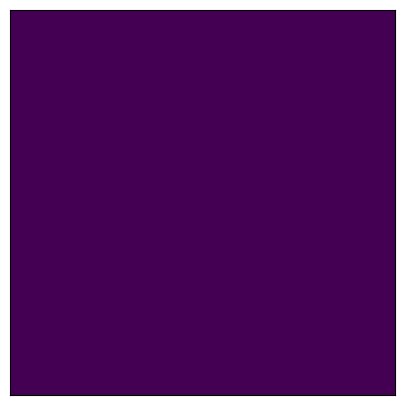

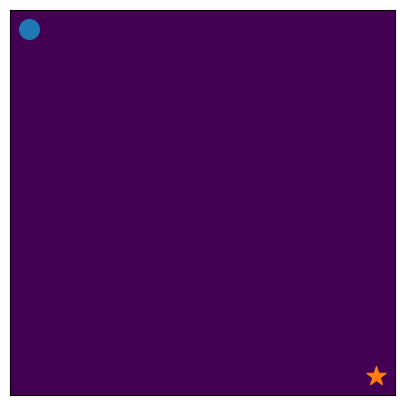

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from queue import PriorityQueue, Queue
from matplotlib import animation
from IPython.display import HTML
import ipywidgets as widgets

# =========================
# Configuração inicial
# =========================
size = 10
maze = np.zeros((size, size))

start = [0,0]
goal = [9,9]

moves = [(-1,0),(1,0),(0,-1),(0,1)]

# =========================
# Heurística
# =========================
def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

# =========================
# BFS
# =========================
def bfs_steps():
    queue = Queue()
    queue.put(tuple(start))

    came_from = {tuple(start): None}
    visited = []

    while not queue.empty():
        current = queue.get()
        visited.append(current)

        if current == tuple(goal):
            break

        for m in moves:
            n = (current[0]+m[0], current[1]+m[1])

            if (0 <= n[0] < size and
                0 <= n[1] < size and
                maze[n] == 0 and
                n not in came_from):

                queue.put(n)
                came_from[n] = current

    return came_from, visited

# =========================
# A*
# =========================
def astar_steps():
    open_set = PriorityQueue()
    open_set.put((0, tuple(start)))

    came_from = {tuple(start): None}
    g = {tuple(start):0}
    visited = []

    while not open_set.empty():
        current = open_set.get()[1]
        visited.append(current)

        if current == tuple(goal):
            break

        for m in moves:
            n = (current[0]+m[0], current[1]+m[1])

            if (0 <= n[0] < size and
                0 <= n[1] < size and
                maze[n] == 0):

                tentative = g[current] + 1

                if n not in g or tentative < g[n]:
                    g[n] = tentative
                    f = tentative + heuristic(n, goal)
                    open_set.put((f, n))
                    came_from[n] = current

    return came_from, visited

# =========================
# Reconstruir caminho
# =========================
def reconstruct(came_from):
    current = tuple(goal)
    path = []

    while current != tuple(start):
        path.append(current)
        current = came_from[current]

    path.append(tuple(start))
    path.reverse()
    return path

# =========================
# Desenhar
# =========================
def draw(grid=None):
    if grid is None:
        grid = maze.copy()

    plt.figure(figsize=(5,5))
    plt.imshow(grid)

    # Pacman
    plt.scatter(start[1], start[0], s=200, marker='o')

    # Comida
    plt.scatter(goal[1], goal[0], s=200, marker='*')

    plt.xticks([])
    plt.yticks([])
    plt.show()

# =========================
# Clique para editar
# =========================
def onclick(event):
    if event.inaxes:
        x = int(event.ydata)
        y = int(event.xdata)

        maze[x,y] = 1 - maze[x,y]
        draw()

# =========================
# Animação
# =========================
def animate(visited, path, title):
    fig, ax = plt.subplots(figsize=(5,5))

    def update(frame):
        ax.clear()
        grid = maze.copy()

        for i in range(frame):
            v = visited[i]
            grid[v] = 0.5

        if frame == len(visited):
            for p in path:
                grid[p] = 0.3

        ax.imshow(grid)
        ax.scatter(start[1], start[0], s=200)
        ax.scatter(goal[1], goal[0], s=200, marker='*')
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    anim = animation.FuncAnimation(
        fig, update,
        frames=len(visited)+1,
        interval=200,
        repeat=False
    )

    return HTML(anim.to_jshtml())

# =========================
# Botões
# =========================
def run_bfs(b):
    came, visited = bfs_steps()
    path = reconstruct(came)
    display(animate(visited, path, "BFS"))

def run_astar(b):
    came, visited = astar_steps()
    path = reconstruct(came)
    display(animate(visited, path, "A*"))

def clear(b):
    global maze
    maze = np.zeros((size,size))
    draw()

# =========================
# UI
# =========================
btn_bfs = widgets.Button(description="Rodar BFS")
btn_astar = widgets.Button(description="Rodar A*")
btn_clear = widgets.Button(description="Limpar")

btn_bfs.on_click(run_bfs)
btn_astar.on_click(run_astar)
btn_clear.on_click(clear)

display(btn_bfs, btn_astar, btn_clear)

# ativar clique
fig = plt.figure(figsize=(5,5))
plt.imshow(maze)
plt.xticks([])
plt.yticks([])
fig.canvas.mpl_connect('button_press_event', onclick)

draw()